# Fase 2 — Modelo Dimensional (Star Schema)
**Asignatura:** Gestión de Datos — UAX  
**Alumno:** Álvaro González Fernández  
**Fecha:** 2026-05-06

Diseño del Data Warehouse `saleshealth_dwh` siguiendo la metodología de Ralph Kimball:

- **Granularidad:** una fila por línea de venta (`sale_item`).
- **Tabla de hechos:** `fact_sales` (centro del esquema, color dorado).
- **Dimensiones:** `dim_customer`, `dim_product`, `dim_store`, `dim_date`, `dim_offer` (color azul).
- **Esquema:** estrella simple (sin jerarquías de copo de nieve) — todas las dimensiones desnormalizadas.

## 1. Definición del esquema en memoria

In [1]:
import os
import sqlite3
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

# Estructura del esquema dimensional
SCHEMA = {
    'fact_sales': {
        'pos': (9.0, 6.0),
        'is_fact': True,
        'columns': [
            ('sale_item_id', 'PK'),
            ('sale_id',      'FK'),
            ('customer_id',  'FK'),
            ('product_id',   'FK'),
            ('store_id',     'FK'),
            ('date_id',      'FK'),
            ('offer_id',     'FK'),
            ('quantity',     'M'),
            ('unit_price',   'M'),
            ('subtotal',     'M'),
            ('unit_cost',    'M'),
            ('margin',       'M'),
        ],
    },
    'dim_customer': {
        'pos': (3.0, 9.6),
        'is_fact': False,
        'columns': [
            ('customer_id', 'PK'),
            ('first_name',  ''),
            ('last_name',   ''),
            ('email',       ''),
            ('phone',       ''),
            ('created_at',  ''),
        ],
    },
    'dim_offer': {
        'pos': (9.0, 10.6),
        'is_fact': False,
        'columns': [
            ('offer_id',         'PK'),
            ('name',             ''),
            ('discount_percent', ''),
            ('start_date',       ''),
            ('end_date',         ''),
        ],
    },
    'dim_product': {
        'pos': (15.0, 9.6),
        'is_fact': False,
        'columns': [
            ('product_id',    'PK'),
            ('name',          ''),
            ('category',      ''),
            ('manufacturer',  ''),
            ('unit_cost',     ''),
            ('unit_price',    ''),
            ('brand_name',    ''),
            ('category_name', ''),
        ],
    },
    'dim_store': {
        'pos': (3.0, 2.4),
        'is_fact': False,
        'columns': [
            ('store_id',         'PK'),
            ('name',             ''),
            ('address',          ''),
            ('city',             ''),
            ('postal_code',      ''),
            ('district',         ''),
            ('area_type',        ''),
            ('zone_orientation', ''),
        ],
    },
    'dim_date': {
        'pos': (15.0, 2.4),
        'is_fact': False,
        'columns': [
            ('date_id',     'PK'),
            ('date',        ''),
            ('year',        ''),
            ('quarter',     ''),
            ('month',       ''),
            ('week',        ''),
            ('day_of_week', ''),
            ('is_weekend',  ''),
        ],
    },
}

print(f'Esquema definido: 1 tabla de hechos + {sum(1 for v in SCHEMA.values() if not v["is_fact"])} dimensiones')
for name, info in SCHEMA.items():
    role = 'HECHOS' if info['is_fact'] else 'DIM'
    print(f'  [{role:6}] {name:15} → {len(info["columns"])} columnas')

Esquema definido: 1 tabla de hechos + 5 dimensiones
  [HECHOS] fact_sales      → 12 columnas
  [DIM   ] dim_customer    → 6 columnas
  [DIM   ] dim_offer       → 5 columnas
  [DIM   ] dim_product     → 8 columnas
  [DIM   ] dim_store       → 8 columnas
  [DIM   ] dim_date        → 8 columnas


## 2. Diagrama del Star Schema

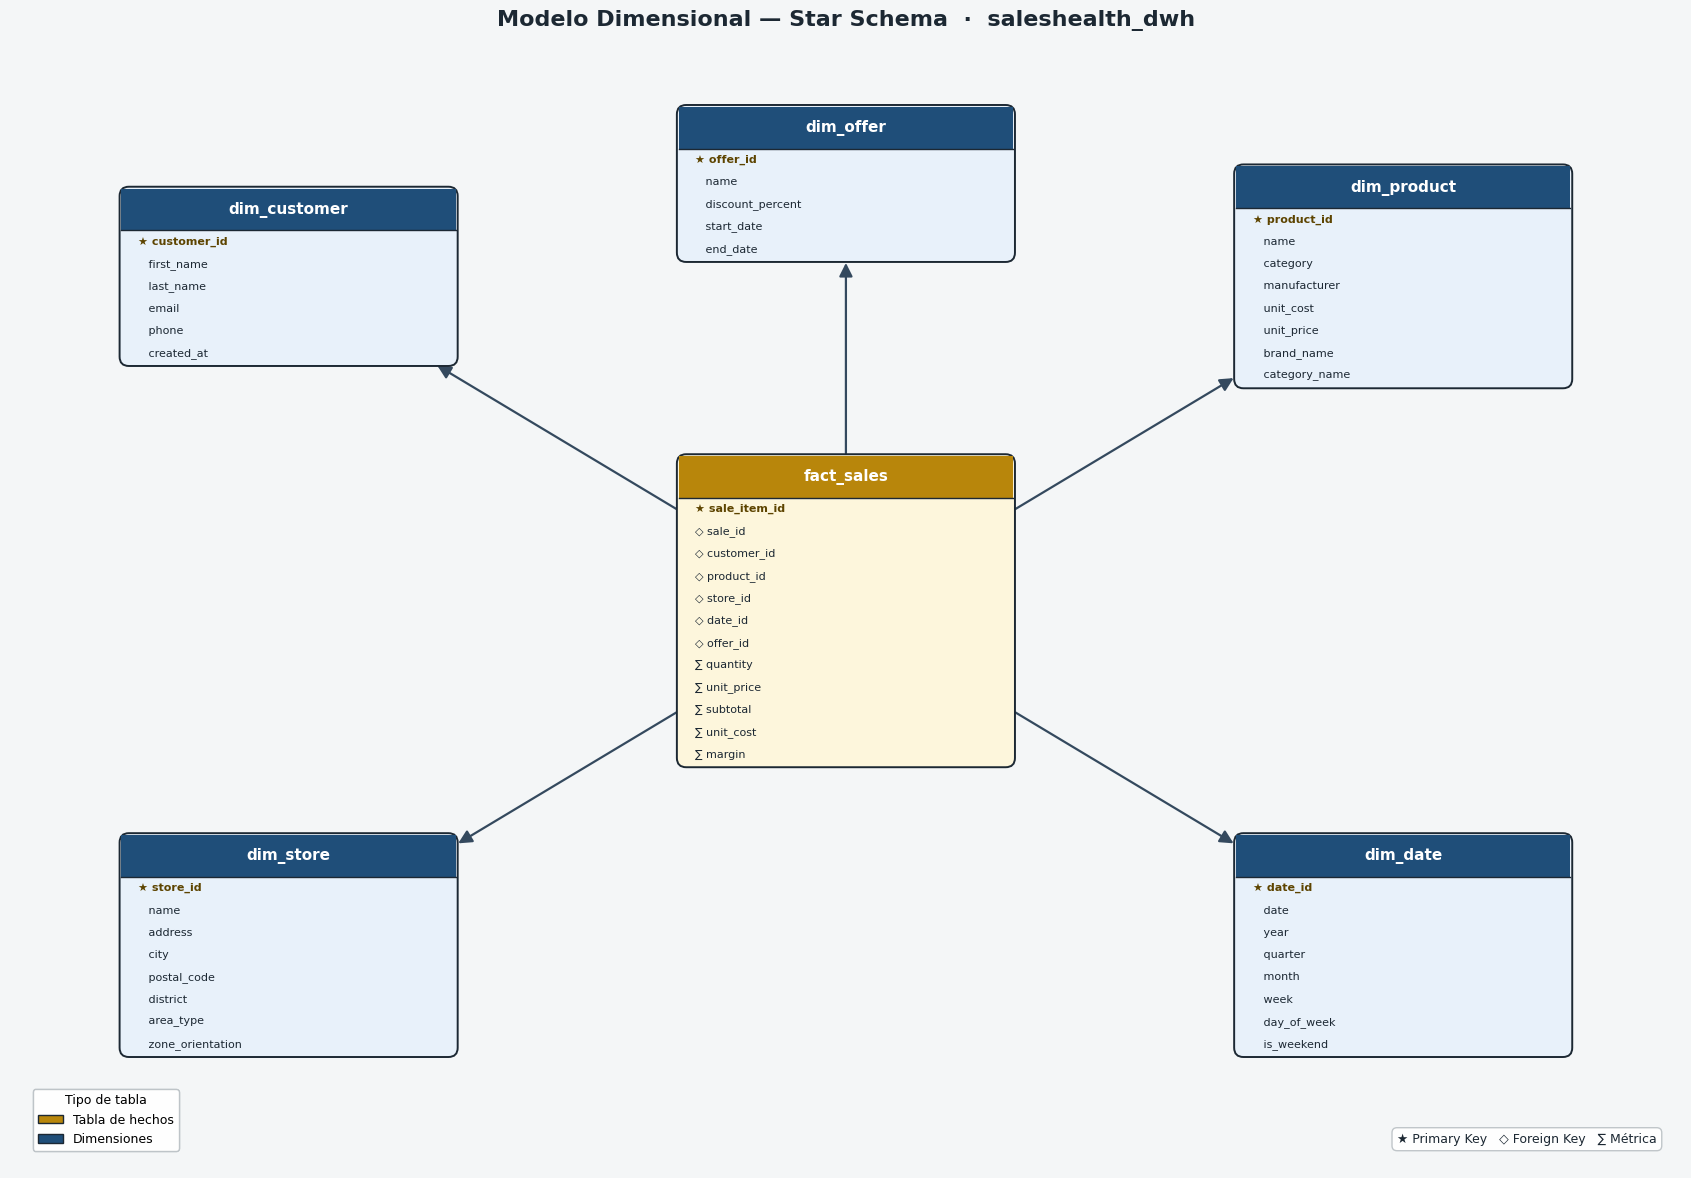

✓ Diagrama guardado como modelo_dimensional.png


In [2]:
# ── Constantes de dibujo ────────────────────────────────────────────────────
BOX_W      = 3.6
HEADER_H   = 0.45
ROW_H      = 0.24

COLOR_FACT_HEADER = '#b8860b'   # dorado oscuro
COLOR_FACT_BODY   = '#fdf6dc'   # crema
COLOR_DIM_HEADER  = '#1f4e79'   # azul oscuro
COLOR_DIM_BODY    = '#e8f1fa'   # azul muy claro
COLOR_BORDER      = '#1c2833'

def box_height(n_cols):
    return HEADER_H + n_cols * ROW_H

def box_edge(cx, cy, w, h, tx, ty):
    """Punto en el borde del rectángulo (cx,cy,w,h) en dirección a (tx,ty)."""
    dx, dy = tx - cx, ty - cy
    if abs(dx) < 1e-9 and abs(dy) < 1e-9:
        return cx, cy
    hw, hh = w/2, h/2
    if abs(dx) < 1e-9:
        s = hh / abs(dy)
    elif abs(dy) < 1e-9:
        s = hw / abs(dx)
    else:
        s = min(hw / abs(dx), hh / abs(dy))
    return cx + dx*s, cy + dy*s

def draw_table(ax, name, info):
    cx, cy = info['pos']
    cols = info['columns']
    h = box_height(len(cols))
    x0, y0 = cx - BOX_W/2, cy - h/2

    if info['is_fact']:
        hdr_col, body_col = COLOR_FACT_HEADER, COLOR_FACT_BODY
    else:
        hdr_col, body_col = COLOR_DIM_HEADER, COLOR_DIM_BODY

    # Cuerpo (rectángulo redondeado)
    ax.add_patch(FancyBboxPatch(
        (x0, y0), BOX_W, h,
        boxstyle='round,pad=0.02,rounding_size=0.10',
        facecolor=body_col, edgecolor=COLOR_BORDER,
        linewidth=1.4, zorder=3,
    ))
    # Cabecera (rectángulo opaco superpuesto en la parte superior)
    ax.add_patch(Rectangle(
        (x0, y0 + h - HEADER_H), BOX_W, HEADER_H,
        facecolor=hdr_col, edgecolor='none', zorder=4,
    ))
    # Línea separadora cabecera/cuerpo
    ax.plot([x0, x0 + BOX_W], [y0 + h - HEADER_H, y0 + h - HEADER_H],
            color=COLOR_BORDER, linewidth=1.0, zorder=5)
    # Nombre de la tabla
    ax.text(cx, y0 + h - HEADER_H/2, name,
            ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', zorder=6)
    # Columnas
    for i, (col, marker) in enumerate(cols):
        y = y0 + h - HEADER_H - (i + 0.5) * ROW_H
        if marker == 'PK':
            prefix, weight, color = '★ ', 'bold', '#5d4400'
        elif marker == 'FK':
            prefix, weight, color = '◇ ', 'normal', '#1c2833'
        elif marker == 'M':
            prefix, weight, color = '∑ ', 'normal', '#1c2833'
        else:
            prefix, weight, color = '   ', 'normal', '#1c2833'
        ax.text(x0 + 0.18, y, f'{prefix}{col}',
                ha='left', va='center', fontsize=8,
                fontweight=weight, color=color, zorder=6)

# ── Figura ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 12))
ax.set_xlim(0, 18)
ax.set_ylim(0, 12)
ax.set_aspect('equal')
ax.axis('off')
ax.set_facecolor('#f4f6f7')
fig.patch.set_facecolor('#f4f6f7')
ax.set_title('Modelo Dimensional — Star Schema  ·  saleshealth_dwh',
             fontsize=16, fontweight='bold', pad=20, color='#1c2833')

# ── Aristas (fact → dimensiones) ─────────────────────────────────────────────
fact_info = SCHEMA['fact_sales']
fcx, fcy  = fact_info['pos']
fact_h    = box_height(len(fact_info['columns']))

for name, info in SCHEMA.items():
    if info['is_fact']:
        continue
    dcx, dcy = info['pos']
    dim_h    = box_height(len(info['columns']))
    fx, fy   = box_edge(fcx, fcy, BOX_W, fact_h, dcx, dcy)
    dx_, dy_ = box_edge(dcx, dcy, BOX_W, dim_h,  fcx, fcy)
    ax.annotate('',
        xy=(dx_, dy_), xytext=(fx, fy),
        arrowprops=dict(arrowstyle='-|>', color='#34495e',
                        lw=1.6, mutation_scale=20),
        zorder=2)

# ── Nodos (tablas) ───────────────────────────────────────────────────────────
for name, info in SCHEMA.items():
    draw_table(ax, name, info)

# ── Leyenda ──────────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(facecolor=COLOR_FACT_HEADER, ec=COLOR_BORDER,
                   label='Tabla de hechos'),
    mpatches.Patch(facecolor=COLOR_DIM_HEADER,  ec=COLOR_BORDER,
                   label='Dimensiones'),
]
leg1 = ax.legend(handles=legend_handles, loc='lower left',
                 fontsize=9, framealpha=0.95, edgecolor='#bdc3c7',
                 title='Tipo de tabla', title_fontsize=9,
                 bbox_to_anchor=(0.01, 0.01))
ax.add_artist(leg1)

# Leyenda de símbolos
ax.text(0.985, 0.02, '★ Primary Key   ◇ Foreign Key   ∑ Métrica',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, color='#1c2833',
        bbox=dict(boxstyle='round,pad=0.4', fc='white',
                  ec='#bdc3c7', alpha=0.95))

plt.tight_layout(pad=1.5)
plt.savefig('modelo_dimensional.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✓ Diagrama guardado como modelo_dimensional.png')

## 3. Script DDL — `crear_dwh.sql`

El script `crear_dwh.sql` contiene los `CREATE TABLE` con todas las restricciones de integridad (PKs, FKs, CHECKs) y los índices recomendados para acelerar los star joins.

In [3]:
with open('crear_dwh.sql', 'r', encoding='utf-8') as f:
    ddl = f.read()

print(ddl)

-- =============================================================================
-- Data Warehouse: saleshealth_dwh
-- Modelo dimensional — Star Schema
-- Motor destino: SQLite 3
-- Autor: Álvaro González Fernández — Gestión de Datos (UAX)
-- =============================================================================

PRAGMA foreign_keys = ON;

-- -----------------------------------------------------------------------------
-- DROPS (idempotencia — permite re-ejecutar el script sin errores)
-- -----------------------------------------------------------------------------
DROP TABLE IF EXISTS fact_sales;
DROP TABLE IF EXISTS dim_customer;
DROP TABLE IF EXISTS dim_product;
DROP TABLE IF EXISTS dim_store;
DROP TABLE IF EXISTS dim_date;
DROP TABLE IF EXISTS dim_offer;

-- =============================================================================
-- DIMENSIONES
-- =============================================================================

-- ------------------------------------------

## 4. Materialización del DWH en SQLite

Creamos físicamente la base de datos `saleshealth_dwh.db` ejecutando el script DDL anterior. La carga de datos (ETL) se realizará en la Fase 3.

In [4]:
DB_PATH = 'saleshealth_dwh.db'

# Recreamos la BD desde cero ejecutando el DDL
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

conn = sqlite3.connect(DB_PATH)
conn.executescript(ddl)
conn.commit()

# Verificación: listar las tablas creadas
cur = conn.cursor()
cur.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;")
created = [r[0] for r in cur.fetchall()]
print(f'Tablas creadas en {DB_PATH}:')
for t in created:
    cur.execute(f'PRAGMA table_info("{t}");')
    n_cols = len(cur.fetchall())
    print(f'  • {t:15} → {n_cols} columnas')

# Verificación: índices
cur.execute("""
    SELECT name FROM sqlite_master
    WHERE type='index' AND name NOT LIKE 'sqlite_%'
    ORDER BY name;
""")
idx = [r[0] for r in cur.fetchall()]
print(f'\nÍndices creados ({len(idx)}):')
for i in idx:
    print(f'  • {i}')

conn.close()
print(f'\n✓ DWH inicializado correctamente en {DB_PATH}')

Tablas creadas en saleshealth_dwh.db:
  • dim_customer    → 6 columnas
  • dim_date        → 8 columnas
  • dim_offer       → 5 columnas
  • dim_product     → 8 columnas
  • dim_store       → 8 columnas
  • fact_sales      → 12 columnas

Índices creados (6):
  • idx_fact_sales_customer
  • idx_fact_sales_date
  • idx_fact_sales_offer
  • idx_fact_sales_product
  • idx_fact_sales_sale
  • idx_fact_sales_store

✓ DWH inicializado correctamente en saleshealth_dwh.db
